In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


from sklearn.metrics import confusion_matrix


from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")



In [2]:
df = pd.read_csv(r"C:\\Users\\User\\Downloads\\Titanic-Dataset (2).zip")

In [50]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [51]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [52]:
df.shape

(891, 12)

In [53]:
df.size

10692

In [54]:
for col in df.columns:
    if df[col].nunique() <=10:
        print(f"\nColumn: {col}")
        print(df[col].unique())


Column: Survived
[0 1]

Column: Pclass
[3 1 2]

Column: Sex
<StringArray>
['male', 'female']
Length: 2, dtype: str

Column: SibSp
[1 0 3 4 2 5 8]

Column: Parch
[0 1 2 5 3 4 6]

Column: Embarked
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [56]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [58]:
df["Age"] = df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df["Cabin"] = df["Cabin"].fillna("Unknown", inplace=True)
df.isnull().sum()




PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [59]:
print(df.duplicated().sum())

0


In [60]:
df.drop(columns=["PassengerId","Name","Ticket"], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,Unknown,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,Unknown,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,Unknown,S


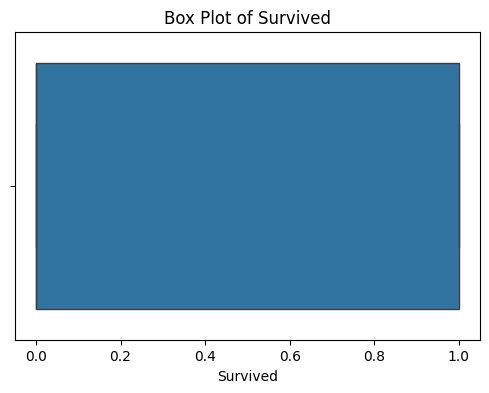

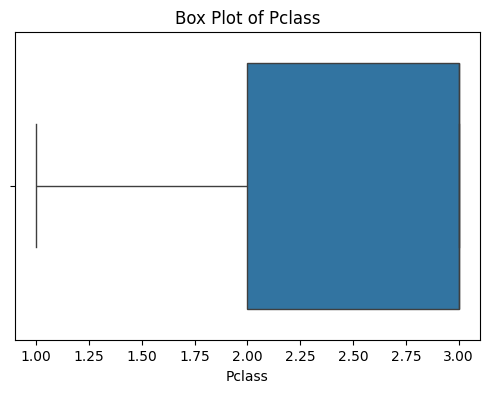

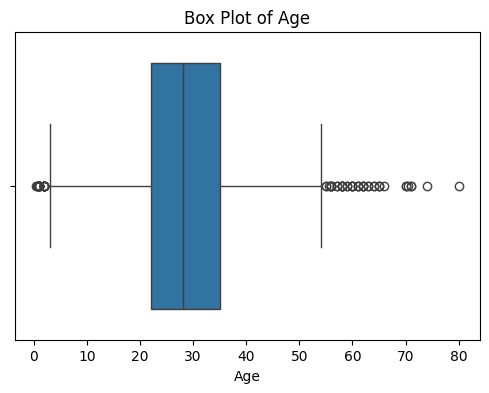

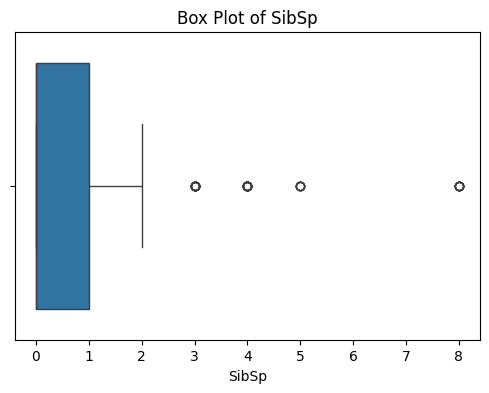

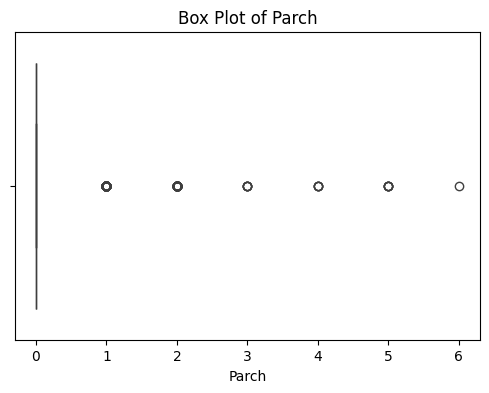

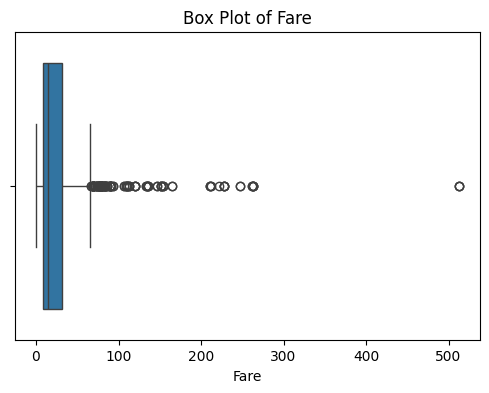

In [61]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [62]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col],lower_bound,upper_bound)
print("Outlier clipping completed.")    
    
    

Outlier clipping completed.


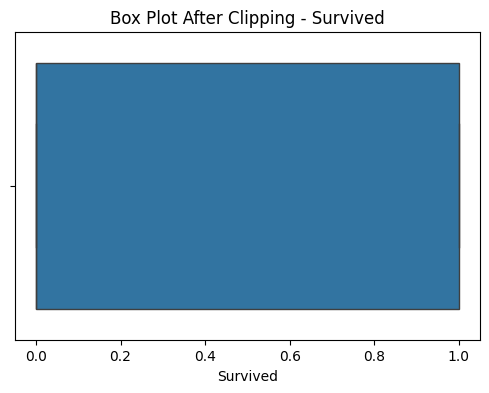

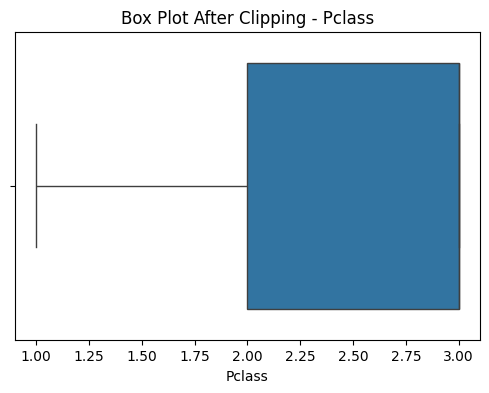

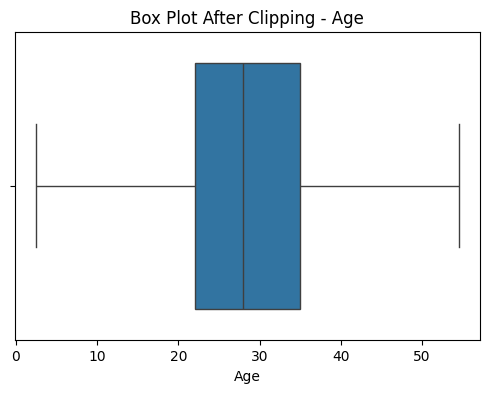

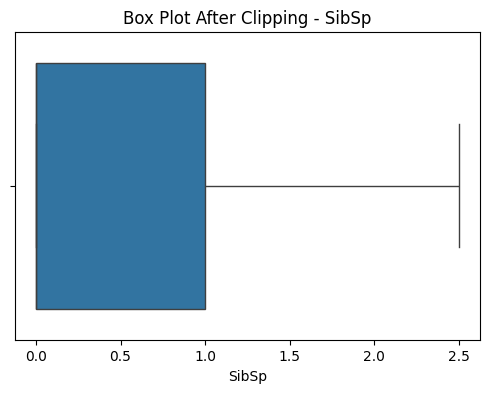

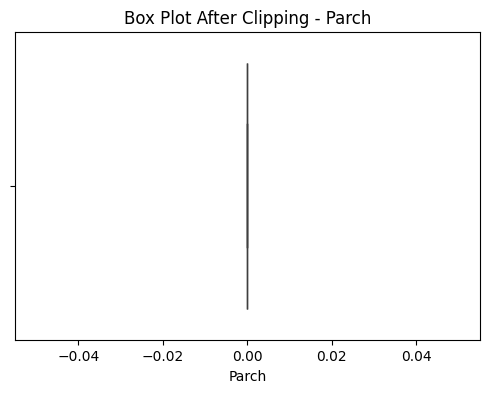

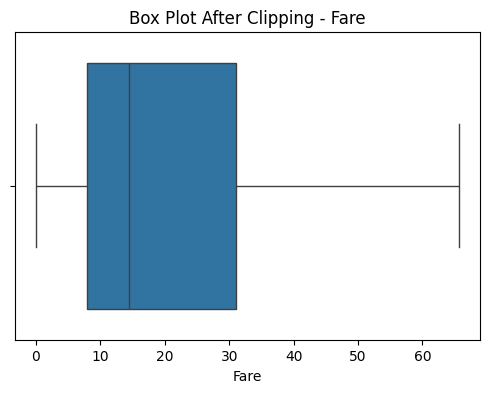

In [63]:

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot After Clipping - {col}")
    plt.show()

In [64]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [65]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [66]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.060622,0.031434,NaN,0.317430
Pclass,-0.338481,1.000000,-0.340404,0.023180,NaN,-0.715300
Age,-0.060622,-0.340404,1.000000,-0.247806,NaN,0.144544
SibSp,0.031434,0.023180,-0.247806,1.000000,NaN,0.349615
Parch,NaN,NaN,NaN,NaN,NaN,NaN
Fare,0.317430,-0.715300,0.144544,0.349615,NaN,1.000000


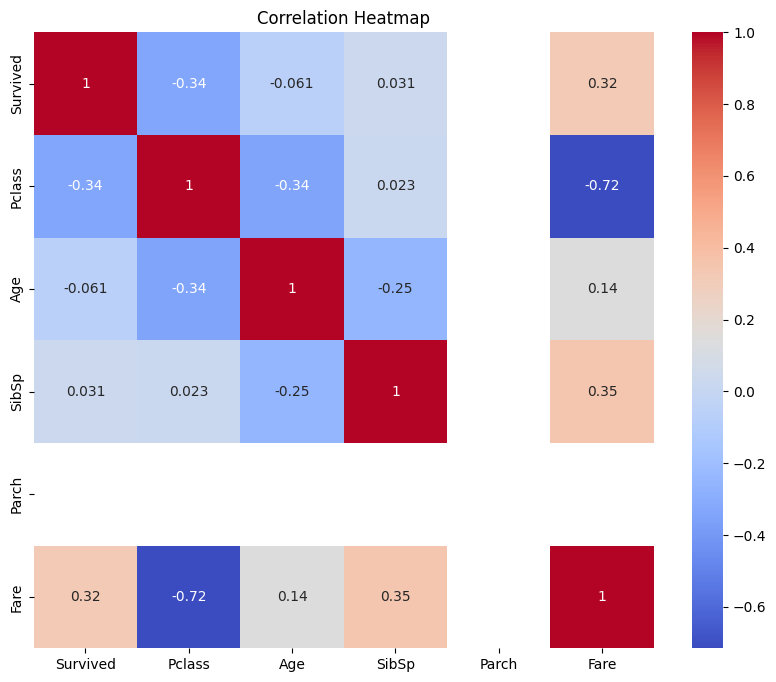

In [67]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

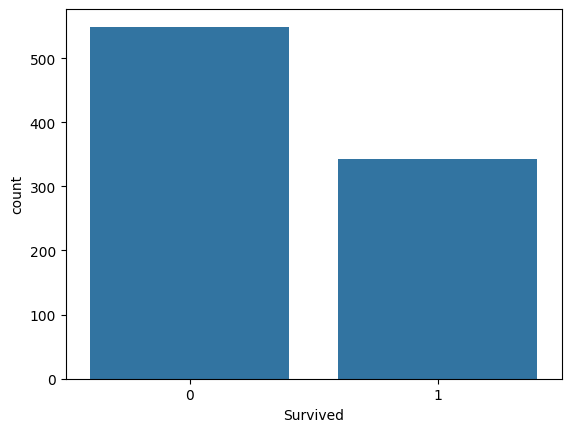

In [68]:
sns.countplot(x="Survived",data=df)
plt.show()

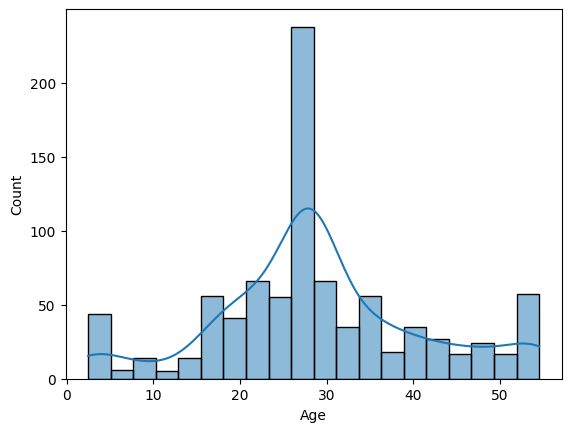

In [69]:
sns.histplot(df["Age"],kde=True)
plt.show()

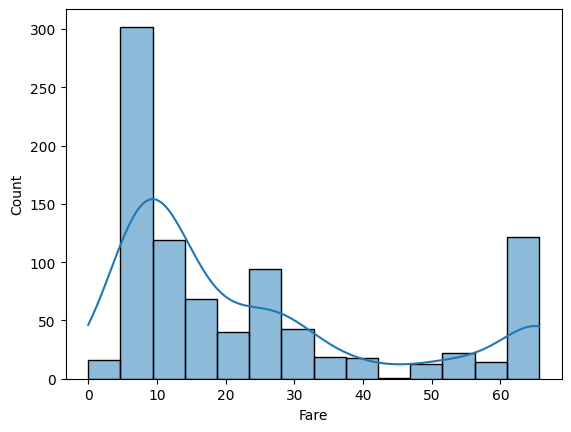

In [70]:
sns.histplot(df["Fare"],kde=True)
plt.show()

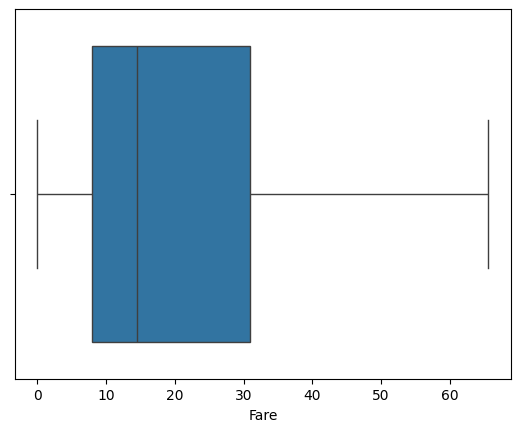

In [71]:
sns.boxplot(x=df["Fare"])
plt.show()

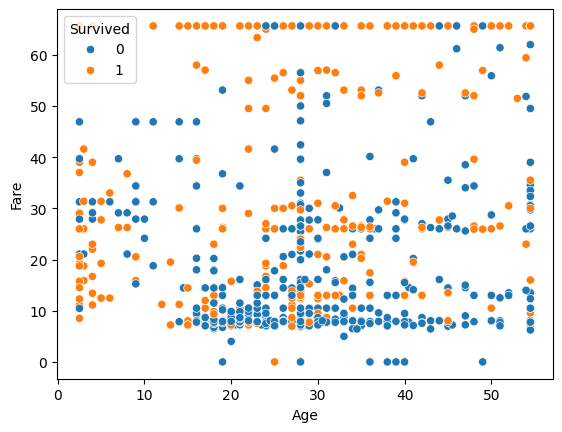

In [72]:
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.show()

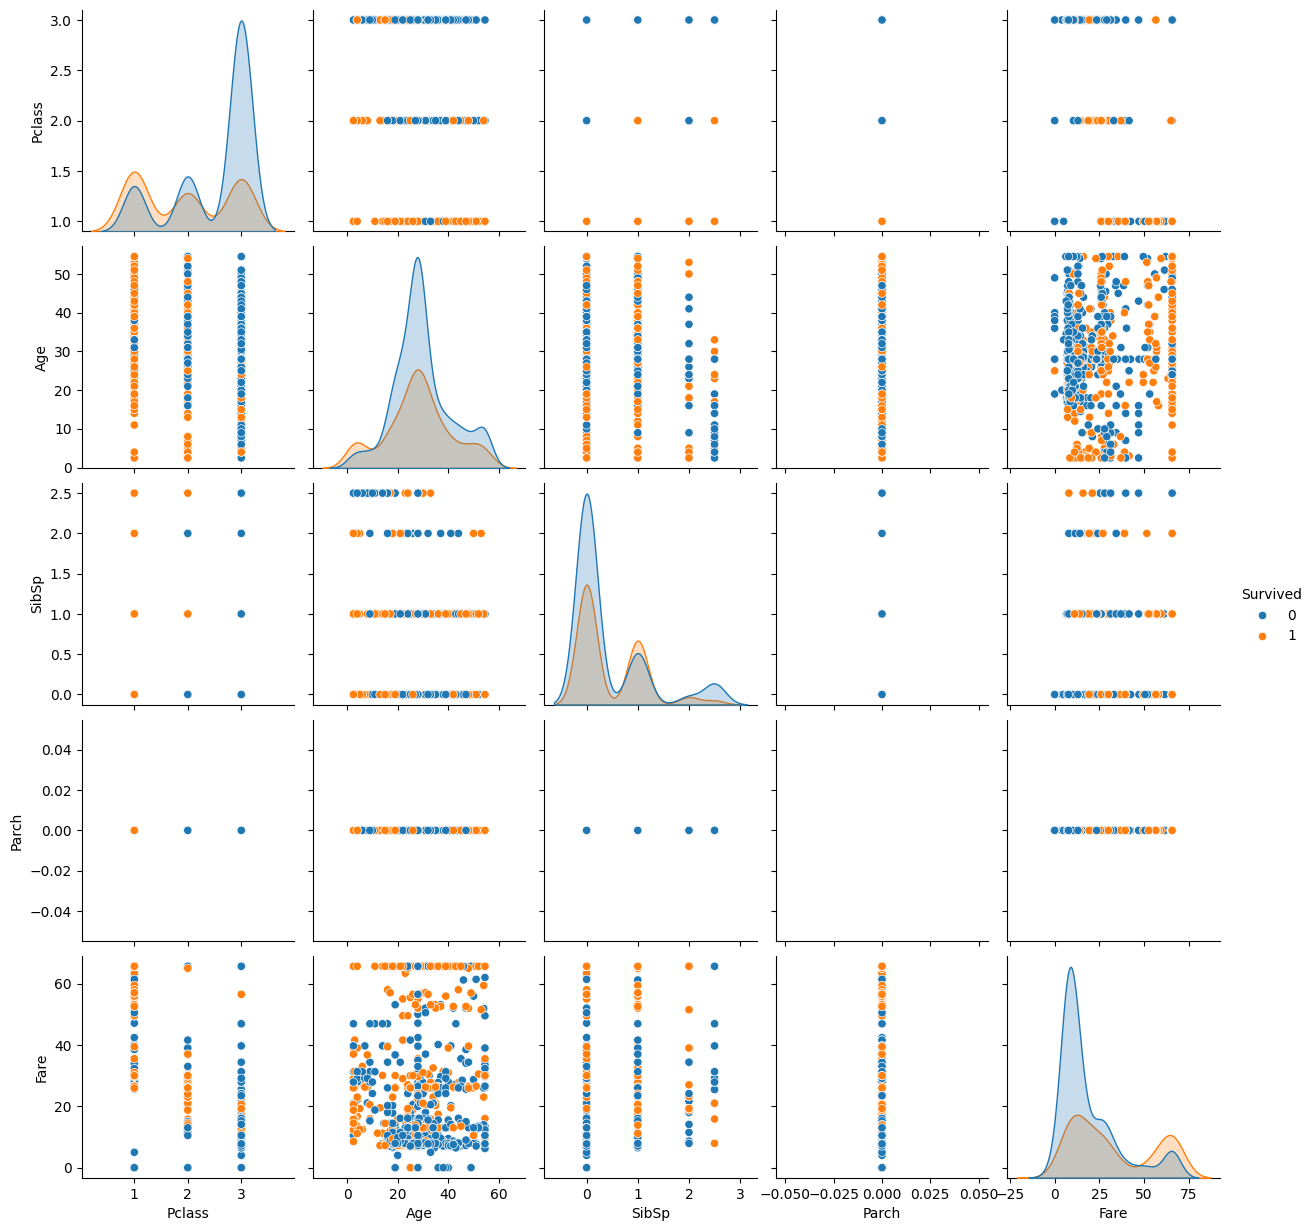

In [73]:
sns.pairplot(df,hue="Survived")
plt.show()

In [74]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

df["Cabin"] = encoder.fit_transform(df["Cabin"])

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1.0,0,7.2500,147,2
1,1,1,0,38.0,1.0,0,65.6344,81,0
2,1,3,0,26.0,0.0,0,7.9250,147,2
3,1,1,0,35.0,1.0,0,53.1000,55,2
4,0,3,1,35.0,0.0,0,8.0500,147,2


In [75]:
X = df.drop("Survived", axis=1)

y = df["Survived"]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0.827377,0.737695,-0.583432,0.810220,0.0,-0.820552,0.451502,0.585954
1,-1.566107,-1.355574,0.742685,0.810220,0.0,2.031623,-1.381627,-1.942303
2,0.827377,-1.355574,-0.251903,-0.602512,0.0,-0.787578,0.451502,0.585954
3,-1.566107,-1.355574,0.494038,0.810220,0.0,1.419297,-2.103768,0.585954
4,0.827377,0.737695,0.494038,-0.602512,0.0,-0.781471,0.451502,0.585954


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)


(712, 8)
(179, 8)


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy : 0.8044692737430168


In [78]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy : 0.7821229050279329


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.8044692737430168


In [80]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Accuracy :", accuracy_score(y_test, knn_pred))


KNN Accuracy : 0.7430167597765364


In [81]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy :", accuracy_score(y_test, svm_pred))

SVM Accuracy : 0.6703910614525139


In [82]:
print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy       :", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy       :", accuracy_score(y_test, rf_pred))
print("KNN Accuracy                 :", accuracy_score(y_test, knn_pred))
print("SVM Accuracy                 :", accuracy_score(y_test, svm_pred))

Logistic Regression Accuracy : 0.8044692737430168
Decision Tree Accuracy       : 0.7821229050279329
Random Forest Accuracy       : 0.8044692737430168
KNN Accuracy                 : 0.7430167597765364
SVM Accuracy                 : 0.6703910614525139


In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)


[[89 16]
 [19 55]]


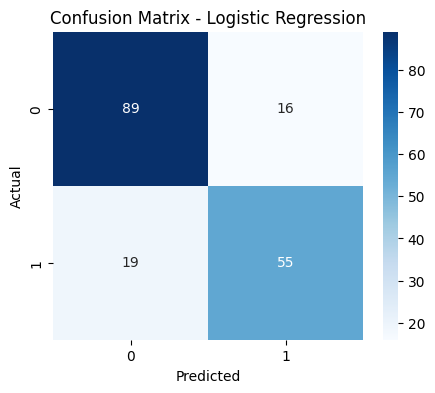

In [84]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [86]:
sample = X.iloc[0:10]

predictions = lr.predict(sample)

results = pd.DataFrame({
    "Actual": y.iloc[0:10].values,
    "Predicted": predictions
})

print(results)

   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       1          1
4       0          0
5       0          0
6       0          0
7       0          0
8       1          1
9       1          1
